In [1]:
%pip install kagglehub
%pip install pandas
%pip install scipy
%pip install matplotlib



   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [40]:
import pandas
df = pandas.read_csv("dataset/games.csv")

In [ ]:
# EDA: Understanding the features of the dataset
print(df.head())
print(df.shape)
df.isnull().sum()

         id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   
2  mIICvQHh   True  1.504130e+12  1.504130e+12     61           mate  white   
3  kWKvrqYL   True  1.504110e+12  1.504110e+12     61           mate  white   
4  9tXo1AUZ   True  1.504030e+12  1.504030e+12     95           mate  white   

  increment_code       white_id  white_rating      black_id  black_rating  \
0           15+2       bourgris          1500          a-00          1191   
1           5+10           a-00          1322     skinnerua          1261   
2           5+10         ischia          1496          a-00          1500   
3           20+0  daniamurashov          1439  adivanov2009          1454   
4           30+3      nik221107          1523  adivanov2009          1469   

                                               moves opening_e

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

In [26]:
#EDA: Visualizing the data
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

output_dir = "EDA"
os.makedirs(output_dir, exist_ok=True)

# Features to plot a scatterplot for
feature_plot = ['rated', 'created_at', 'last_move_at', 'turns', 'increment_code', 'black_rating', 'opening_ply']

# Scatterplot
for i in range(1, len(df.columns)):
    if df.columns[i] in feature_plot:
        filename = f'{df.columns[i]}_vs_white_rating_scatter'
        filepath = os.path.join(output_dir, filename)

        plt.figure(figsize=(12, 6))
        plt.scatter(df[df.columns[i]], df['white_rating'])
        plt.ylabel('WHITE RATING')
        plt.xlabel(df.columns[i].upper())
        plt.savefig(filepath)
        plt.close()

# Features to calculate pcc for
feature_pcc = ['rated', 'created_at', 'last_move_at', 'turns', 'black_rating', 'opening_ply']

# Format of dictionary will be:   Key = Feature | Value = [correlation coefficient, p_value]
pcc_dict = {}
# Pearson Correlation Coefficient
for column in df.columns:
    if column in feature_pcc:
        corr_co, p_value = pearsonr(df[column], df['white_rating'])
        pcc_dict[column] = (corr_co, p_value)

# Store values in a txt file
with open("EDA/pcc_values.txt", 'w') as file:
    json.dump(pcc_dict, file, indent=4)

In [ ]:
# EDA: Examining increment_code feature
# Seeing if there is a relationship between increment_code and white_rating,
# but ensuring that the opening sample size is large enough to be meaningful
eco_stats = df.groupby("opening_eco")["white_rating"].agg(["mean","count"])
eco_stats_filtered = eco_stats[eco_stats["count"] > 50]
eco_stats_filtered.sort_values("mean", ascending=False).head(20)

,mean,count
opening_eco,,
B90,1772.376238,101
B13,1761.388235,85
E20,1758.454545,77
E61,1744.423729,59
A46,1741.240506,79
A15,1737.250000,60
D35,1733.069444,72
B22,1726.510638,94
B40,1713.844961,129


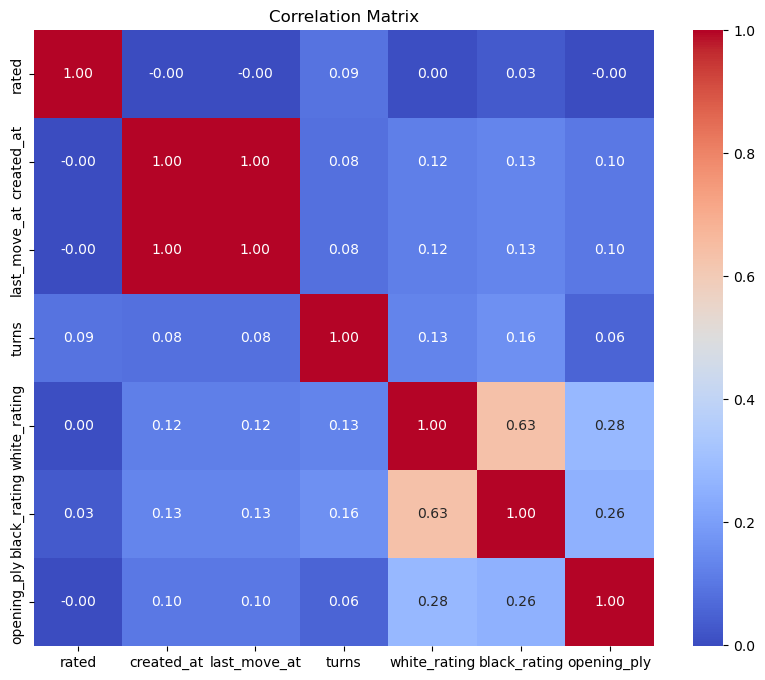

In [32]:

numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [37]:
# ------- Clean data --------

# Replace true and false if we haven't already
if (df['rated'].dtype == bool):
    mapping = {"rated": {True: 1, False: 0}}

    # Map the labels to values
    for col, m in mapping.items():
        df[col] = df[col].map(m)
# Make time increment from categorical to numerical
df[["base_time", "increment"]] = df["increment_code"].str.split("+", expand=True).astype(int)
# Drop original time control column
df = df.drop(columns=["increment_code"])
# Use one hot encoding for the following features
one_hot_encoded = pandas.get_dummies(df, columns=['victory_status', 'opening_eco', 'winner'], drop_first=True, dtype=int)
one_hot_encoded.to_csv('dataset/clean_games.csv', index=False)

In [39]:

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

df_clean = pandas.read_csv("dataset/clean_games.csv")
print(df_clean.shape)

(20058, 383)
